Import Libraries (استدعاء المكتبات)


In [185]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Read CSV file and convert it into a DataFrame

In [186]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')

Display first 5 rows of the dataset

In [187]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0



Show dataset structure and data type




In [188]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [189]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Handle Missing Values

In [190]:
df['Income'].fillna(df['Income'].median(), inplace=True)

/tmp/ipykernel_1161/1959487941.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


In [191]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Create Age column from Year of Birth

In [193]:
df['Age'] = 2025 - df['Year_Birth']

Create TotalSpending by summing all spending columns

In [194]:
df['TotalSpending'] = (
    df['MntWines']
    + df['MntFruits']
    + df['MntMeatProducts']
    + df['MntFishProducts']
    + df['MntSweetProducts']
    + df['MntGoldProds']
)
df['TotalSpending']

,TotalSpending
0,1617
1,27
2,776
3,53
4,422
...,...
2235,1341
2236,444
2237,1241
2238,843


create TotalChildren by summing kids and teens at hom

In [195]:
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']
df['TotalChildren']

,TotalChildren
0,0
1,2
2,0
3,1
4,1
...,...
2235,1
2236,3
2237,0
2238,1


Remove unrealistic ages (below 18 or above 100)

In [196]:
df = df[(df['Age']>=18) & (df['Age']<=100) ]

Remove rows with zero income

In [197]:
df = df[df['Income'] > 0]

Convert Education categories into numerical values


Drop date column (not numberical)


In [198]:
df = df.drop('Dt_Customer', axis=1)

In [199]:
df['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [201]:
education_map = {
    'Basic':0,
    'Graduation':1,
    'Master':2,
    'PhD':3,
    '2n Cycle':4
}

df['Education'] = df['Education'].map(education_map)

Select top 4 most frequent marital status categorie

In [202]:
top4 = df['Marital_Status'].value_counts().nlargest(4).index

Group less frequent categories into "Other"

In [203]:
df['Marital_Status'] = df['Marital_Status'].apply(
    lambda x: x if x in top4 else 'Other'
)

Apply One-Hot Encoding to marital status

In [204]:
df = pd.get_dummies(
    df,
    columns=['Marital_Status'],
    drop_first=True
)

In [205]:
df.head()


,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,Z_CostContact,Z_Revenue,Response,Age,TotalSpending,TotalChildren,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together
0,5524,1957,NaN,58138.0,0,0,58,635,88,546,...,3,11,1,68,1617,0,False,False,True,False
1,2174,1954,NaN,46344.0,1,1,38,11,1,6,...,3,11,0,71,27,2,False,False,True,False
2,4141,1965,NaN,71613.0,0,0,26,426,49,127,...,3,11,0,60,776,0,False,False,False,True
3,6182,1984,NaN,26646.0,1,0,26,11,4,20,...,3,11,0,41,53,1,False,False,False,True
4,5324,1981,NaN,58293.0,1,0,94,173,43,118,...,3,11,0,44,422,1,True,False,False,False


In [137]:
df['TotalSpending']

,TotalSpending
0,1617
1,27
2,776
3,53
4,422
...,...
2235,1341
2236,444
2237,1241
2238,843


Set the figure size for better visualization


---



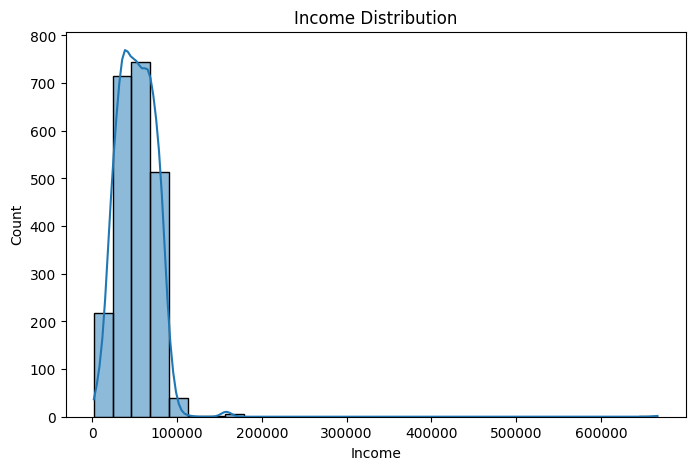

In [66]:
plt.figure(figsize=(8,5))
sns.histplot(df['Income'], bins=30, kde=True)
plt.title("Income Distribution")
plt.show()

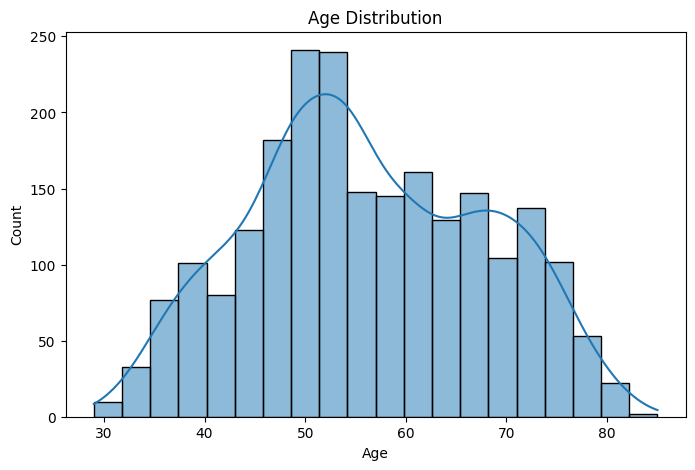

In [65]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

Correlation Heatmap

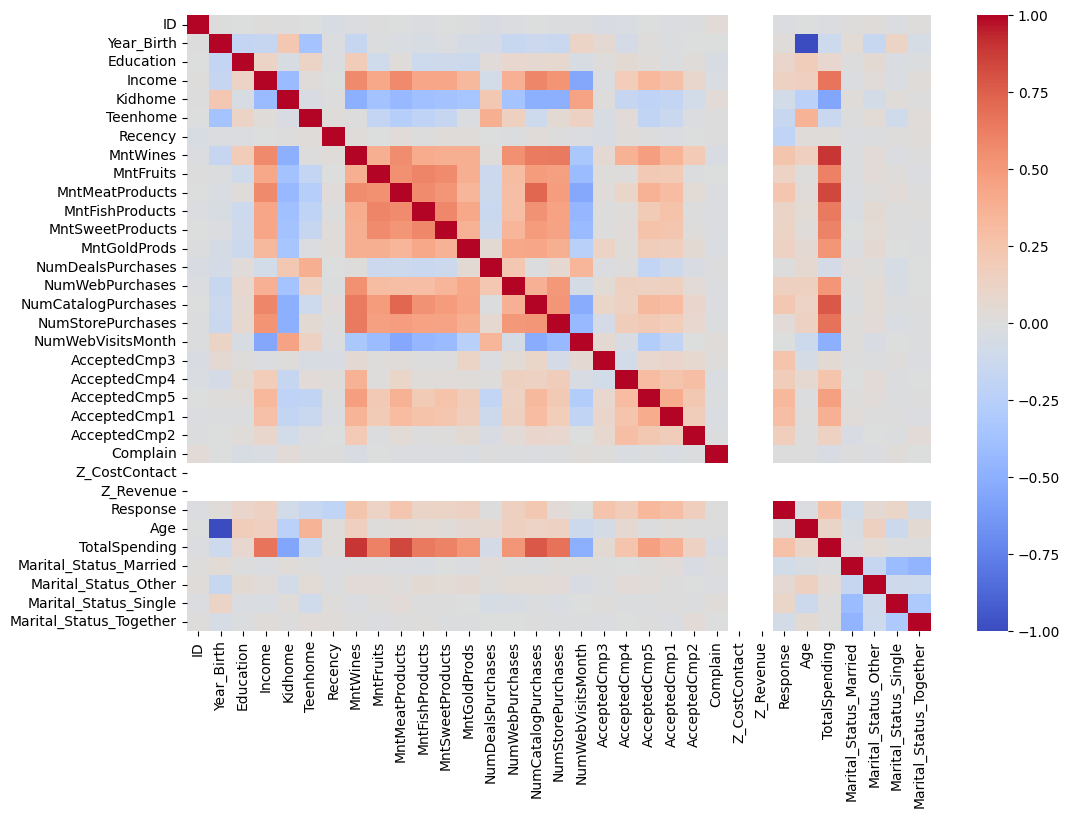

In [64]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)
plt.show()

Define target variable

In [67]:
y = df['TotalSpending']

Define features




In [69]:
X = df.drop([
    'TotalSpending',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
], axis=1)

Split dataset

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Apply feature scaling

In [72]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Train Linear Regression model&Predict using Linear Regression





In [78]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

Train Ridge Regression model& Predict using Ridg











In [79]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

Train Decision Tree model & Predict using Decision Tree


In [80]:
tree = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

Evaluate models using MSE, RMSE, and R2

In [81]:
results_reg = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Decision Tree'
    ],
    'MSE': [
        mean_squared_error(y_test, lr_pred),
        mean_squared_error(y_test, ridge_pred),
        mean_squared_error(y_test, tree_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, tree_pred))
    ],
    'R2': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, tree_pred)
    ]
})

results_reg

,Model,MSE,RMSE,R2
0,Linear Regression,70858.993917,266.193527,0.813467
1,Ridge Regression,70848.507827,266.173830,0.813495
2,Decision Tree,54619.354753,233.707841,0.856217


show the distribution of the target variable Respons






In [82]:
df['Response'].value_counts()

,count
Response,
0,1903
1,334


show the distribution of the target variable Respons





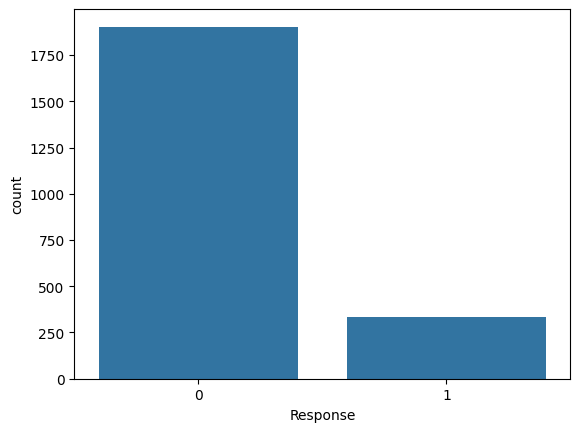

In [83]:
sns.countplot(
    x='Response',
    data=df
)

plt.show()

Define features and targe






In [84]:
X = df.drop('Response', axis=1)

y = df['Response']

Split dataset with stratification

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Scale data

In [88]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Logistic Regression

In [211]:
log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

Knn

In [212]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

Random Forest

In [213]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

Classification Evaluation

In [214]:
def evaluate_model(name, y_true, y_pred):

    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy:",
          accuracy_score(y_true, y_pred))

    print("Precision:",
          precision_score(y_true, y_pred))

    print("Recall:",
          recall_score(y_true, y_pred))

    print("F1:",
          f1_score(y_true, y_pred))

    print("\nClassification Report\n")

    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(name)
    plt.show()

Logistic Regression
Accuracy: 0.8125
Precision: 0.43089430894308944
Recall: 0.7910447761194029
F1: 0.5578947368421052

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.82      0.88       381
           1       0.43      0.79      0.56        67

    accuracy                           0.81       448
   macro avg       0.69      0.80      0.72       448
weighted avg       0.88      0.81      0.83       448



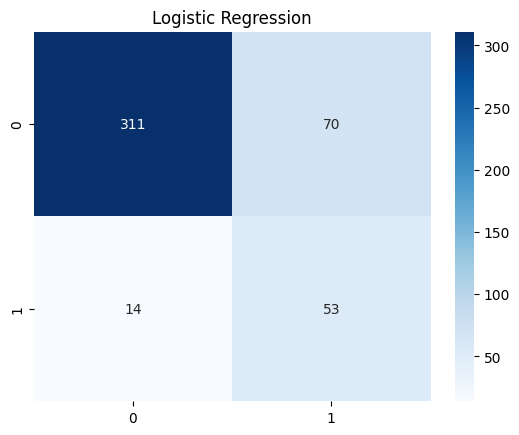

In [215]:
evaluate_model(
    "Logistic Regression",
    y_test,
    log_pred
)

KNN
Accuracy: 0.875
Precision: 0.6571428571428571
Recall: 0.34328358208955223
F1: 0.45098039215686275

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       381
           1       0.66      0.34      0.45        67

    accuracy                           0.88       448
   macro avg       0.78      0.66      0.69       448
weighted avg       0.86      0.88      0.86       448



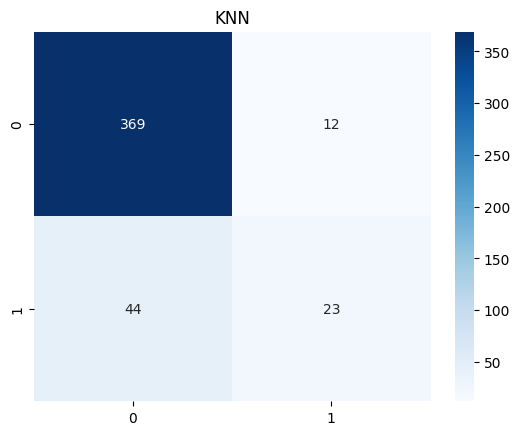

In [97]:
evaluate_model(
    "KNN",
    y_test,
    knn_pred
)

Random Forest
Accuracy: 0.875
Precision: 0.6896551724137931
Recall: 0.29850746268656714
F1: 0.4166666666666667

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.98      0.93       381
           1       0.69      0.30      0.42        67

    accuracy                           0.88       448
   macro avg       0.79      0.64      0.67       448
weighted avg       0.86      0.88      0.85       448



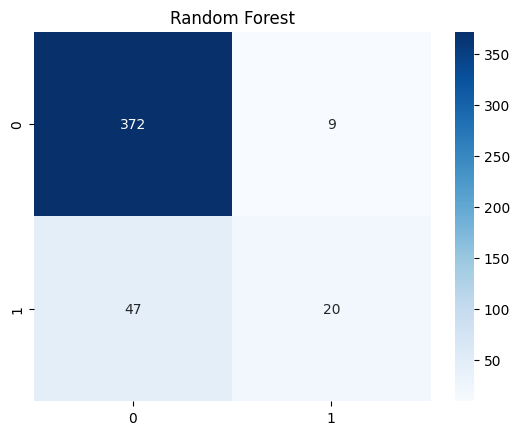

In [98]:
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

Select clustering feature

In [100]:
cluster_features = [
    'Income',
    'TotalSpending',
    'Age',
    'TotalChildren'
]

Elbow Method

In [107]:
inertia = []

for k in range(1, 11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_cluster)

    inertia.append(km.inertia_)

Plot Elbow

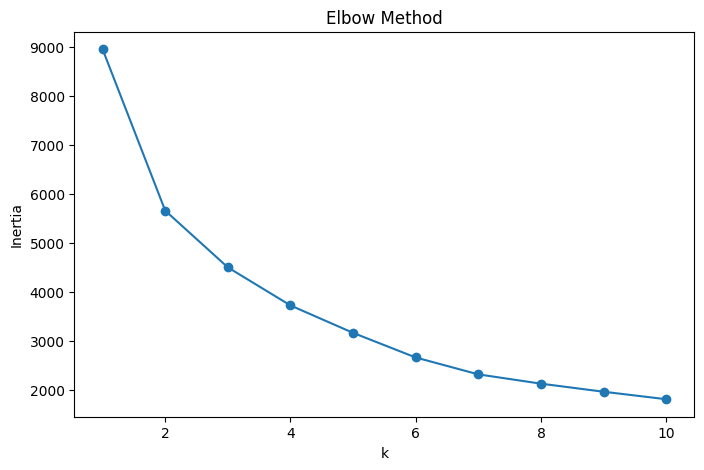

In [108]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

Fit final KMeans (k=3)

In [216]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster)

In [110]:
df['Cluster']

,Cluster
0,1
1,0
2,1
3,2
4,2
...,...
2235,1
2236,0
2237,1
2238,1


PCA visualization

In [111]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

components = pca.fit_transform(X_cluster)

Scatter plot









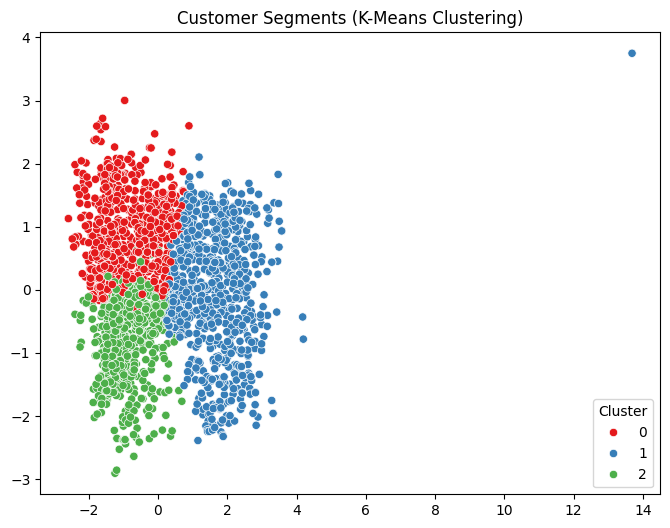

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=components[:,0],
    y=components[:,1],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segments (K-Means Clustering)")
plt.show()

Cluster profiling

In [113]:
cluster_profile = df.groupby('Cluster')[[
    'Income',
    'TotalSpending',
    'Age',
    'TotalChildren'
]].mean()

cluster_profile

,Income,TotalSpending,Age,TotalChildren
Cluster,,,,
0,47278.929577,298.545070,62.940845,1.690141
1,74150.170854,1289.276382,57.640704,0.391960
2,33161.607387,159.804378,47.772914,0.841313
